# 1. Importations et Préparation

In [1]:
import os
import glob
from pathlib import Path
from typing import List, Tuple, Dict, Optional, Any

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn import model_selection, metrics
from tqdm import tqdm

# PyTorch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

# Augmentation d'images
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device utilisé : {DEVICE}")
print(f"PyTorch version : {torch.__version__}")

Device utilisé : cpu
PyTorch version : 2.9.1+cpu


# 2. Configuration et Hyperparamètres

In [2]:
# ============================================
# CHEMINS
# ============================================
DATA_DIR = Path("C:/Users/htalbi/workspace/projet_API/data/captcha_images_v2")
MODELS_DIR = Path("C:/Users/htalbi/workspace/projet_API/models")

# ============================================
# PARAMÈTRES DU MODÈLE (ORIGINAUX)
# ============================================
IMAGE_WIDTH = 300
IMAGE_HEIGHT = 75
CAPTCHA_LENGTH = 5

# ============================================
# PARAMÈTRES D'ENTRAÎNEMENT (ORIGINAUX)
# ============================================
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 3e-4    # 0.0003
PATIENCE = 10

# ============================================
# SPLIT DES DONNÉES
# ============================================
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

print(f"Nombre de fichiers : {len(list(DATA_DIR.glob('*.png')))}")

Nombre de fichiers : 1040


# 3. Chargement et Analyse des Données

In [3]:
def load_data(data_dir: Path) -> Tuple[List[str], List[str], List[str]]:
    """
    Liste les chemins des images et extrait les labels des noms de fichiers.

    Args:
        data_dir: Chemin vers le dossier contenant les images.

    Returns:
        Un triplet (chemins_images, labels, vocabulaire).
    """
    image_paths: List[str] = sorted(glob.glob(str(data_dir / "*.png")))
    labels: List[str] = [Path(x).stem for x in image_paths]
    characters: List[str] = sorted(set("".join(labels)))

    return image_paths, labels, characters


# Chargement
image_paths, labels, vocab = load_data(DATA_DIR)


ANALYSE DU DATASET
Nombre d'images : 1040
Vocabulaire (19 caractères) : ['2', '3', '4', '5', '6', '7', '8', 'b', 'c', 'd', 'e', 'f', 'g', 'm', 'n', 'p', 'w', 'x', 'y']
Longueur des CAPTCHAs : {5}

Distribution des caractères :
Caractère  Fréquence  Pourcentage
        2        265         5.10
        3        267         5.13
        4        284         5.46
        5        281         5.40
        6        259         4.98
        7        258         4.96
        8        264         5.08
        b        240         4.62
        c        262         5.04
        d        259         4.98
        e        235         4.52
        f        271         5.21
        g        271         5.21
        m        275         5.29
        n        525        10.10
        p        253         4.87
        w        235         4.52
        x        264         5.08
        y        232         4.46

Total caractères : 5200
Min fréquence : 232 (y)
Max fréquence : 525 (n)


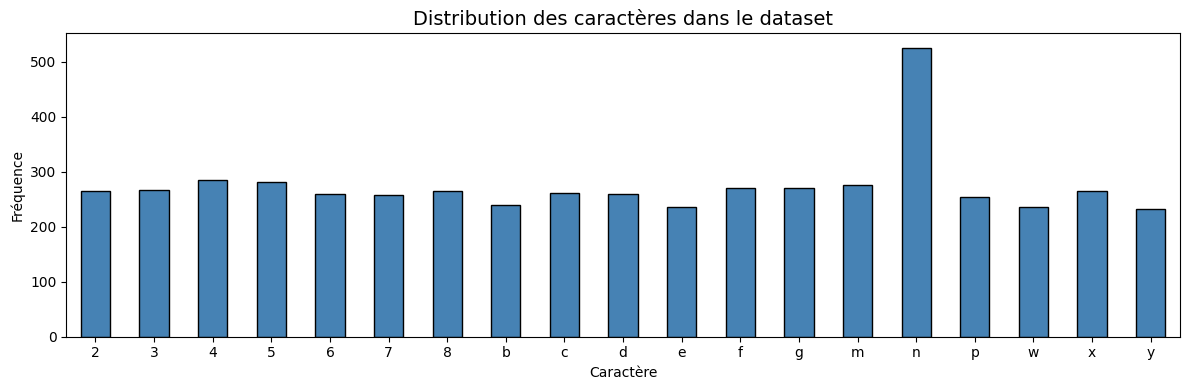

In [4]:
# Analyse du dataset
print("ANALYSE DU DATASET")
print(f"Nombre d'images : {len(image_paths)}")
print(f"Vocabulaire ({len(vocab)} caractères) : {vocab}")
print(f"Longueur des CAPTCHAs : {set(len(l) for l in labels)}")
print()

# Distribution des caractères
all_chars = "".join(labels)
char_counts = pd.Series(list(all_chars)).value_counts().sort_index()

# Affichage en tableau
print("Distribution des caractères :")
distribution_df = pd.DataFrame({
    "Caractère": char_counts.index,
    "Fréquence": char_counts.values,
    "Pourcentage": (char_counts.values / char_counts.sum() * 100).round(2)
})
print(distribution_df.to_string(index=False))
print()
print(f"Total caractères : {char_counts.sum()}")

if not char_counts.empty:
    print(f"Min fréquence : {char_counts.min()} ({char_counts.idxmin()})")
    print(f"Max fréquence : {char_counts.max()} ({char_counts.idxmax()})")

    # Visualisation
    fig, ax = plt.subplots(figsize=(12, 4))
    char_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title("Distribution des caractères dans le dataset", fontsize=14)
    ax.set_xlabel("Caractère")
    ax.set_ylabel("Fréquence")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Min fréquence : N/A (aucun caractère trouvé)")
    print("Max fréquence : N/A (aucun caractère trouvé)")
    print("Impossible de visualiser la distribution : le dataset de caractères est vide.")


# 4. Encodage des Labels (Caractère ↔ Nombre)

In [5]:
class CaptchaDataset(Dataset):
    """
    Dataset personnalisé pour charger les images de CAPTCHA et leurs labels encodés.
    """
    def __init__(
        self,
        image_paths: List[str],
        targets: List[List[int]],
        resize: Tuple[int, int]
    ) -> None:
        """
        Initialise le dataset avec les chemins, les cibles et la taille cible.
        """
        self.image_paths = image_paths
        self.targets = targets
        self.resize = resize # (Hauteur, Largeur)

        # Normalisation standard ImageNet
        self.aug = albumentations.Compose([
            albumentations.Normalize(
                mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225),
                always_apply=True
            )
        ])

    def __len__(self) -> int:
        """Retourne le nombre total d'exemples."""
        return len(self.image_paths)

    def __getitem__(self, item: int) -> Dict[str, torch.Tensor]:
        """
        Récupère un échantillon (image + label) par son index.
        """
        # Chargement et conversion RGB
        image = Image.open(self.image_paths[item]).convert("RGB")

        # Redimensionnement
        image = image.resize((self.resize[1], self.resize[0]), resample=Image.BILINEAR)
        image = np.array(image)

        # Augmentation/Normalisation
        augmented = self.aug(image=image)
        image = augmented["image"]

        # Conversion format PyTorch (H, W, C) -> (C, H, W)
        image = np.transpose(image, (2, 0, 1)).astype(np.float32)

        return {
            "images": torch.tensor(image, dtype=torch.float),
            "targets": torch.tensor(self.targets[item], dtype=torch.long),
        }

In [6]:
# Création des dictionnaires de mapping
# Index 0 réservé pour le "blank" (CTC loss)
char_to_num: Dict[str, int] = {char: idx + 1 for idx, char in enumerate(vocab)}
num_to_char: Dict[int, str] = {idx: char for char, idx in char_to_num.items()}

def encode_label(label: str) -> List[int]:
    """
    Transforme une chaîne de caractères en liste d'entiers.

    Args:
        label: Le texte du CAPTCHA (ex: "2n5bb").

    Returns:
        Liste d'indices (ex: [1, 15, 4, 8, 8]).
    """
    return [char_to_num[c] for c in label]


def decode_label(encoded: List[int]) -> str:
    """
    Transforme une liste d'entiers en chaîne de caractères.

    Args:
        encoded: Liste d'indices.

    Returns:
        Le texte décodé.
    """
    return "".join([num_to_char[idx] for idx in encoded if idx != 0])


# Encodage de tous les labels
targets: List[List[int]] = [encode_label(label) for label in labels]

# Affichage du mapping
print("Dictionnaire de traduction :")
print("-" * 30)
mapping_df = pd.DataFrame({
    "Caractère": list(char_to_num.keys()),
    "Index": list(char_to_num.values())
})
print(mapping_df.to_string(index=False))
print("-" * 30)
print(f"Index 0 = 'blank' (caractère vide pour CTC)")
print()

# Test de l'encodage/décodage
test_label = labels[0]
test_encoded = encode_label(test_label)
test_decoded = decode_label(test_encoded)
print(f"Test : '{test_label}' → {test_encoded} → '{test_decoded}'")

Dictionnaire de traduction :
------------------------------
Caractère  Index
        2      1
        3      2
        4      3
        5      4
        6      5
        7      6
        8      7
        b      8
        c      9
        d     10
        e     11
        f     12
        g     13
        m     14
        n     15
        p     16
        w     17
        x     18
        y     19
------------------------------
Index 0 = 'blank' (caractère vide pour CTC)

Test : '226md' → [1, 1, 5, 14, 10] → '226md'


# 5. Dataset PyTorch avec Data Augmentation

In [8]:
class CaptchaDataset(Dataset):
    """
    Dataset personnalisé pour charger les images de CAPTCHA.
    """
    def __init__(
        self,
        image_paths: List[str],
        targets: List[List[int]],
        resize: Tuple[int, int],
        augment: bool = False
    ) -> None:
        self.image_paths = image_paths
        self.targets = targets
        self.resize = resize
        self.augment = augment

        # Augmentation pour l'entraînement
        self.train_transform = A.Compose([
            A.Rotate(limit=5, p=0.5),
            A.GaussNoise(std_range=(0.02, 0.05), p=0.3),
            A.GaussianBlur(blur_limit=(3, 3), p=0.2),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

        # Transformation simple pour validation/test
        self.val_transform = A.Compose([
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, item: int) -> Dict[str, torch.Tensor]:
        # Chargement en RGB
        image = Image.open(self.image_paths[item]).convert("RGB")

        # Redimensionnement
        image = image.resize((self.resize[1], self.resize[0]), resample=Image.BILINEAR)
        image = np.array(image)

        # Transformation
        transform = self.train_transform if self.augment else self.val_transform
        transformed = transform(image=image)
        image = transformed["image"]

        return {
            "images": image,
            "targets": torch.tensor(self.targets[item], dtype=torch.long),
        }


print("Dataset créé")

Dataset créé


In [9]:
# Test du dataset
test_dataset = CaptchaDataset(
    image_paths=image_paths[:5],
    targets=targets[:5],
    resize=(IMAGE_HEIGHT, IMAGE_WIDTH),
    augment=True
)

print(f"Dataset créé avec {len(test_dataset)} images")
sample = test_dataset[0]
print(f"Shape image : {sample['images'].shape}")
print(f"Shape target : {sample['targets'].shape}")
print(f"Target : {sample['targets'].tolist()} → '{decode_label(sample['targets'].tolist())}'")


Dataset créé avec 5 images
Shape image : torch.Size([3, 75, 300])
Shape target : torch.Size([5])
Target : [1, 1, 5, 14, 10] → '226md'


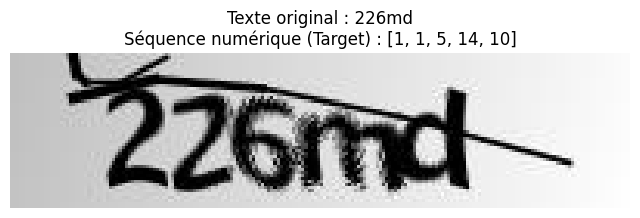

In [10]:
def show_sample(image_path: str, target: List[int]) -> None:
    """
    Affiche une image CAPTCHA avec son texte et encodage.
    """
    image = Image.open(image_path).convert("RGB")
    label = Path(image_path).stem

    plt.figure(figsize=(8, 4))
    plt.imshow(image)
    plt.title(f"Texte original : {label}\nSéquence numérique (Target) : {target}")
    plt.axis("off")
    plt.show()


show_sample(image_paths[0], targets[0])

# 6. Visualisation des Augmentations

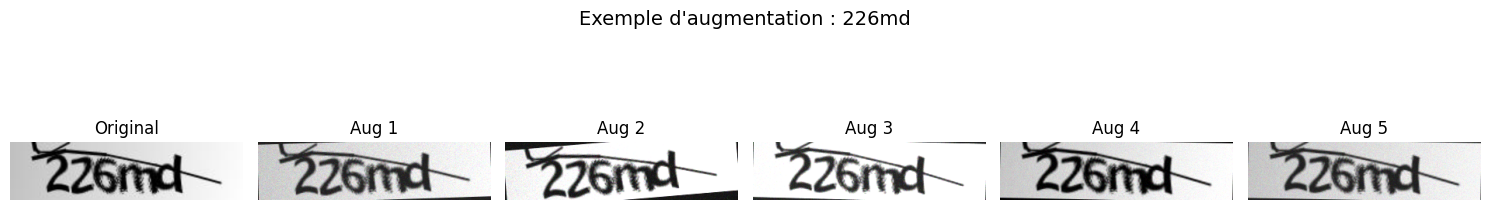

In [11]:
def show_augmentation_examples(image_path: str, n_examples: int = 5) -> None:
    """
    Affiche une image originale et plusieurs versions augmentées.
    """
    image = Image.open(image_path).convert("RGB")
    image = image.resize((IMAGE_WIDTH, IMAGE_HEIGHT), resample=Image.BILINEAR)
    image_array = np.array(image)

    aug_transform = A.Compose([
        A.Rotate(limit=5, p=1.0),
        A.GaussNoise(std_range=(0.02, 0.05), p=1.0),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
    ])

    fig, axes = plt.subplots(1, n_examples + 1, figsize=(15, 3))

    axes[0].imshow(image_array)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i in range(n_examples):
        augmented = aug_transform(image=image_array)["image"]
        axes[i + 1].imshow(augmented)
        axes[i + 1].set_title(f"Aug {i + 1}")
        axes[i + 1].axis("off")

    plt.suptitle(f"Exemple d'augmentation : {Path(image_path).stem}", fontsize=14)
    plt.tight_layout()
    plt.show()


show_augmentation_examples(image_paths[0])

# 7. Split des Données (Train / Validation / Test)

In [12]:
# Premier split : séparer Test (10%) du reste (90%)
train_val_paths, test_paths, train_val_targets, test_targets = model_selection.train_test_split(
    image_paths,
    targets,
    test_size=TEST_RATIO,
    random_state=SEED
)

# Deuxième split : séparer Train (80%) et Validation (10%) à partir des 90% restants
# Note : 0.10 / 0.90 ≈ 0.111 pour obtenir 10% du total
val_size_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

train_paths, val_paths, train_targets, val_targets = model_selection.train_test_split(
    train_val_paths,
    train_val_targets,
    test_size=val_size_adjusted,
    random_state=SEED
)

# Affichage du résumé
print("=" * 50)
print("SPLIT DES DONNÉES")
print("=" * 50)

split_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test", "Total"],
    "Images": [len(train_paths), len(val_paths), len(test_paths), len(image_paths)],
    "Pourcentage": [
        f"{len(train_paths)/len(image_paths)*100:.1f}%",
        f"{len(val_paths)/len(image_paths)*100:.1f}%",
        f"{len(test_paths)/len(image_paths)*100:.1f}%",
        "100%"
    ]
})
print(split_df.to_string(index=False))

SPLIT DES DONNÉES
   Dataset  Images Pourcentage
     Train     831       79.9%
Validation     105       10.1%
      Test     104       10.0%
     Total    1040        100%


# 8. Création des DataLoaders

In [13]:
# Création des datasets
train_dataset = CaptchaDataset(
    image_paths=train_paths,
    targets=train_targets,
    resize=(IMAGE_HEIGHT, IMAGE_WIDTH),
    augment=True  # Augmentation activée pour le train
)

val_dataset = CaptchaDataset(
    image_paths=val_paths,
    targets=val_targets,
    resize=(IMAGE_HEIGHT, IMAGE_WIDTH),
    augment=False  # Pas d'augmentation pour la validation
)

test_dataset = CaptchaDataset(
    image_paths=test_paths,
    targets=test_targets,
    resize=(IMAGE_HEIGHT, IMAGE_WIDTH),
    augment=False  # Pas d'augmentation pour le test
)

# Création des DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Résumé
print("=" * 50)
print(" DATALOADERS CRÉÉS")
print("=" * 50)

loader_df = pd.DataFrame({
    "DataLoader": ["Train", "Validation", "Test"],
    "Images": [len(train_dataset), len(val_dataset), len(test_dataset)],
    "Batches": [len(train_loader), len(val_loader), len(test_loader)],
    "Batch Size": [BATCH_SIZE, BATCH_SIZE, BATCH_SIZE],
    "Augmentation": ["Oui", "Non", "Non"]
})
print(loader_df.to_string(index=False))

 DATALOADERS CRÉÉS
DataLoader  Images  Batches  Batch Size Augmentation
     Train     831      104           8          Oui
Validation     105       14           8          Non
      Test     104       13           8          Non


# 9. Architecture du Modèle CRNN

In [14]:
class CaptchaModel(nn.Module):
    """
    Modèle CRNN pour la reconnaissance de CAPTCHAs.
    Architecture : CNN + Bidirectional GRU + CTC
    """
    def __init__(self, num_chars: int) -> None:
        super().__init__()

        # 1. CNN
        self.conv_1 = nn.Conv2d(3, 128, kernel_size=(3, 6), padding=(1, 1))
        self.pool_1 = nn.MaxPool2d(kernel_size=(2, 2))

        self.conv_2 = nn.Conv2d(128, 64, kernel_size=(3, 6), padding=(1, 1))
        self.pool_2 = nn.MaxPool2d(kernel_size=(2, 2))

        # 2. Transition
        self.linear_1 = nn.Linear(1152, 64)
        self.drop_1 = nn.Dropout(0.2)

        # 3. RNN (GRU bidirectionnel)
        self.gru = nn.GRU(  # ← Renommé de self.lstm à self.gru
            input_size=64,
            hidden_size=32,
            num_layers=2,
            bidirectional=True,
            dropout=0.25,
            batch_first=True
        )

        # 4. Sortie
        self.output = nn.Linear(64, num_chars + 1)

    def forward(
        self,
        images: torch.Tensor,
        targets: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        bs = images.size(0)
        device = images.device

        # CNN
        x = F.relu(self.conv_1(images))
        x = self.pool_1(x)
        x = F.relu(self.conv_2(x))
        x = self.pool_2(x)

        # Reshape pour RNN
        x = x.permute(0, 3, 1, 2)
        x = x.view(bs, x.size(1), -1)

        # Linear + Dropout
        x = F.relu(self.linear_1(x))
        x = self.drop_1(x)

        # RNN
        x, _ = self.gru(x)  # ← Renommé de self.lstm à self.gru

        # Sortie
        x = self.output(x)
        x = x.permute(1, 0, 2)

        if targets is not None:
            log_probs = F.log_softmax(x, dim=2)
            input_lengths = torch.full((bs,), x.size(0), dtype=torch.long, device=device)
            target_lengths = torch.full((bs,), targets.size(1), dtype=torch.long, device=device)

            loss = nn.CTCLoss(blank=0, zero_infinity=True)(
                log_probs, targets, input_lengths, target_lengths
            )
            return x, loss

        return x, None


# Création du modèle
model = CaptchaModel(num_chars=len(vocab))
model.to(DEVICE)



CaptchaModel(
  (conv_1): Conv2d(3, 128, kernel_size=(3, 6), stride=(1, 1), padding=(1, 1))
  (pool_1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv_2): Conv2d(128, 64, kernel_size=(3, 6), stride=(1, 1), padding=(1, 1))
  (pool_2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (linear_1): Linear(in_features=1152, out_features=64, bias=True)
  (drop_1): Dropout(p=0.2, inplace=False)
  (gru): GRU(64, 32, num_layers=2, batch_first=True, dropout=0.25, bidirectional=True)
  (output): Linear(in_features=64, out_features=20, bias=True)
)

In [15]:
# Résumé du model
total_params = sum(p.numel() for p in model.parameters())
print("=" * 50)
print("MODÈLE CRNN")
print("=" * 50)
print(f"Vocabulaire : {len(vocab)} caractères")
print(f"Paramètres totaux : {total_params:,}")
print(f"Device : {DEVICE}")

MODÈLE CRNN
Vocabulaire : 19 caractères
Paramètres totaux : 267,284
Device : cpu


# 10. Fonctions de Décodage CTC

In [16]:
def decode_predictions(preds: torch.Tensor, mapping: Dict[int, str]) -> List[str]:
    """
    Décode les sorties du modèle en texte avec l'algorithme CTC greedy correct.

    Règle CTC :
    1. Collapse les répétitions consécutives (sur séquence brute avec blanks)
    2. Supprime les blanks

    Args:
        preds: Tensor de prédictions (T, B, C).
        mapping: Dictionnaire {index: caractère}.

    Returns:
        Liste des textes décodés.
    """
    # (T, B, C) → (B, T, C)
    preds = preds.permute(1, 0, 2)
    preds = torch.softmax(preds, dim=2)
    preds = torch.argmax(preds, dim=2)
    preds = preds.detach().cpu().numpy()

    results: List[str] = []
    blank_idx = 0  # Index du blank dans CTC

    for batch_idx in range(preds.shape[0]):
        sequence = preds[batch_idx]

        # Décodage CTC greedy correct
        decoded_chars: List[str] = []
        prev_idx = blank_idx  # Commence avec blank

        for idx in sequence:
            # Ajouter le caractère si :
            # 1. Ce n'est pas un blank ET
            # 2. C'est différent du précédent (collapse répétitions)
            if idx != blank_idx and idx != prev_idx:
                decoded_chars.append(mapping[idx])

            prev_idx = idx

        results.append("".join(decoded_chars))

    return results




# 11. Entraînement avec Early Stopping

In [19]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    learning_rate: float,
    patience: int
) -> Dict[str, List[float]]:
    """
    Entraîne le modèle avec Early Stopping.

    Args:
        model: Le modèle à entraîner.
        train_loader: DataLoader d'entraînement.
        val_loader: DataLoader de validation.
        epochs: Nombre maximum d'epochs.
        learning_rate: Taux d'apprentissage initial.
        patience: Nombre d'epochs sans amélioration avant arrêt.

    Returns:
        Historique des losses (train et validation).
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # Historique pour les graphiques
    history = {
        "train_loss": [],
        "val_loss": []
    }

    # Early Stopping
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    best_model_state = None

    print("=" * 60)
    print("DÉBUT DE L'ENTRAÎNEMENT")
    print("=" * 60)

    for epoch in range(epochs):
        # ============================================
        # PHASE D'ENTRAÎNEMENT
        # ============================================
        model.train()
        train_loss = 0.0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in train_pbar:
            images = batch["images"].to(DEVICE)
            targets = batch["targets"].to(DEVICE)

            optimizer.zero_grad()
            _, loss = model(images, targets)
            loss.backward()

            # Gradient clipping pour éviter l'explosion des gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

            optimizer.step()
            train_loss += loss.item()
            train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_train_loss = train_loss / len(train_loader)

        # ============================================
        # PHASE DE VALIDATION
        # ============================================
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Valid]")
            for batch in val_pbar:
                images = batch["images"].to(DEVICE)
                targets = batch["targets"].to(DEVICE)

                _, loss = model(images, targets)
                val_loss += loss.item()
                val_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_val_loss = val_loss / len(val_loader)

        # Sauvegarde de l'historique
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)

        # Mise à jour du scheduler
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(avg_val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        # Affichage du résumé
        print(f"\nEpoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {new_lr:.6f}")

        # Afficher si le LR a changé
        if new_lr < old_lr:
            print(f"Learning rate réduit : {old_lr:.6f} → {new_lr:.6f}")

        # ============================================
        # EARLY STOPPING
        # ============================================
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
            best_model_state = model.state_dict().copy()
            print(f"Nouveau meilleur modèle sauvegardé (Val Loss: {best_val_loss:.4f})")
        else:
            epochs_without_improvement += 1
            print(f"Pas d'amélioration depuis {epochs_without_improvement} epoch(s)")

            if epochs_without_improvement >= patience:
                print(f"\nEarly Stopping déclenché après {epoch+1} epochs")
                break

    # Restaurer le meilleur modèle
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nMeilleur modèle restauré (Val Loss: {best_val_loss:.4f})")

    print("=" * 60)
    print("ENTRAÎNEMENT TERMINÉ")
    print("=" * 60)

    return history


# Lancer l'entraînement
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE
)

DÉBUT DE L'ENTRAÎNEMENT


Epoch 1/50 [Train]:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 1/50 [Valid]: 100%|██████████| 14/14 [00:05<00:00,  2.39it/s, loss=3.2015]



Epoch 1/50 | Train Loss: 5.6089 | Val Loss: 3.2700 | LR: 0.000300
Nouveau meilleur modèle sauvegardé (Val Loss: 3.2700)


Epoch 2/50 [Valid]: 100%|██████████| 14/14 [00:04<00:00,  2.89it/s, loss=3.1545]


...


Epoch 48/50 | Train Loss: 0.0827 | Val Loss: 0.0229 | LR: 0.000300
Nouveau meilleur modèle sauvegardé (Val Loss: 0.0229)


Epoch 49/50 [Valid]: 100%|██████████| 14/14 [00:02<00:00,  6.65it/s, loss=0.0207]



Epoch 49/50 | Train Loss: 0.0808 | Val Loss: 0.0167 | LR: 0.000300
Nouveau meilleur modèle sauvegardé (Val Loss: 0.0167)


Epoch 50/50 [Valid]: 100%|██████████| 14/14 [00:02<00:00,  6.65it/s, loss=0.0130]


Epoch 50/50 | Train Loss: 0.0719 | Val Loss: 0.0138 | LR: 0.000300
Nouveau meilleur modèle sauvegardé (Val Loss: 0.0138)

Meilleur modèle restauré (Val Loss: 0.0138)
ENTRAÎNEMENT TERMINÉ


# 12. Visualisation des Courbes d'Entraînement

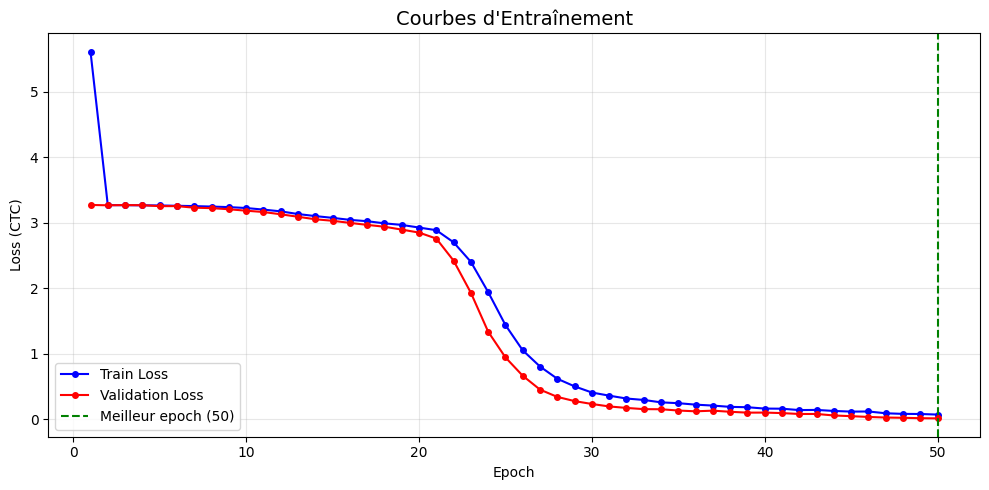

Meilleur epoch : 50
Meilleure Val Loss : 0.0138
Train Loss finale : 0.0719


In [20]:
def plot_training_history(history: Dict[str, List[float]]) -> None:
    """
    Affiche les courbes de loss (train vs validation).

    Args:
        history: Dictionnaire contenant les losses par epoch.
    """
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history["train_loss"], "b-o", label="Train Loss", markersize=4)
    plt.plot(epochs, history["val_loss"], "r-o", label="Validation Loss", markersize=4)

    # Marquer le meilleur epoch
    best_epoch = np.argmin(history["val_loss"]) + 1
    best_val_loss = min(history["val_loss"])
    plt.axvline(x=best_epoch, color="green", linestyle="--", label=f"Meilleur epoch ({best_epoch})")

    plt.title("Courbes d'Entraînement", fontsize=14)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (CTC)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Résumé
    print(f"Meilleur epoch : {best_epoch}")
    print(f"Meilleure Val Loss : {best_val_loss:.4f}")
    print(f"Train Loss finale : {history['train_loss'][-1]:.4f}")


# Afficher les courbes 
plot_training_history(history)

# 13. Métriques d'Évaluation (Accuracy & CER)

In [21]:
def edit_distance(s1: str, s2: str) -> int:
    """
    Calcule la distance de Levenshtein entre deux chaînes.
    (Nombre minimum d'opérations pour transformer s1 en s2)
    """
    if len(s1) < len(s2):
        return edit_distance(s2, s1)

    if len(s2) == 0:
        return len(s1)

    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row

    return previous_row[-1]


def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    mapping: Dict[int, str]
) -> Tuple[float, float, List[str], List[str]]:
    """
    Évalue le modèle et calcule les métriques.

    Args:
        model: Le modèle entraîné.
        loader: DataLoader à évaluer.
        mapping: Dictionnaire {index: caractère}.

    Returns:
        Tuple (accuracy, cer, prédictions, labels réels).
    """
    model.eval()

    all_preds: List[str] = []
    all_targets: List[str] = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Évaluation"):
            images = batch["images"].to(DEVICE)
            targets = batch["targets"]

            preds, _ = model(images)
            decoded_preds = decode_predictions(preds, mapping)
            all_preds.extend(decoded_preds)

            # Décoder les targets
            for t in targets:
                target_text = "".join([mapping[idx.item()] for idx in t if idx.item() != 0])
                all_targets.append(target_text)

    # Calcul de l'Accuracy (mots parfaitement corrects)
    correct = sum(p == t for p, t in zip(all_preds, all_targets))
    accuracy = correct / len(all_targets) * 100

    # Calcul du CER (Character Error Rate)
    total_cer = sum(edit_distance(p, t) for p, t in zip(all_preds, all_targets))
    total_chars = sum(len(t) for t in all_targets)
    cer = total_cer / total_chars * 100

    return accuracy, cer, all_preds, all_targets


# Fonction d'affichage des résultats
def print_evaluation_results(accuracy: float, cer: float, dataset_name: str) -> None:
    """Affiche les résultats d'évaluation."""
    print("=" * 50)
    print(f"RÉSULTATS SUR {dataset_name.upper()}")
    print("=" * 50)
    print(f"Accuracy (mots parfaits) : {accuracy:.2f}%")
    print(f"CER (taux d'erreur caractères) : {cer:.2f}%")
    print("=" * 50)


accuracy, cer, preds, targets = evaluate_model(model, test_loader, num_to_char)
print_evaluation_results(accuracy, cer, "Test")

Évaluation: 100%|██████████| 13/13 [00:01<00:00,  7.17it/s]

RÉSULTATS SUR TEST
Accuracy (mots parfaits) : 98.08%
CER (taux d'erreur caractères) : 0.38%


# 14. Visualisation des Erreurs

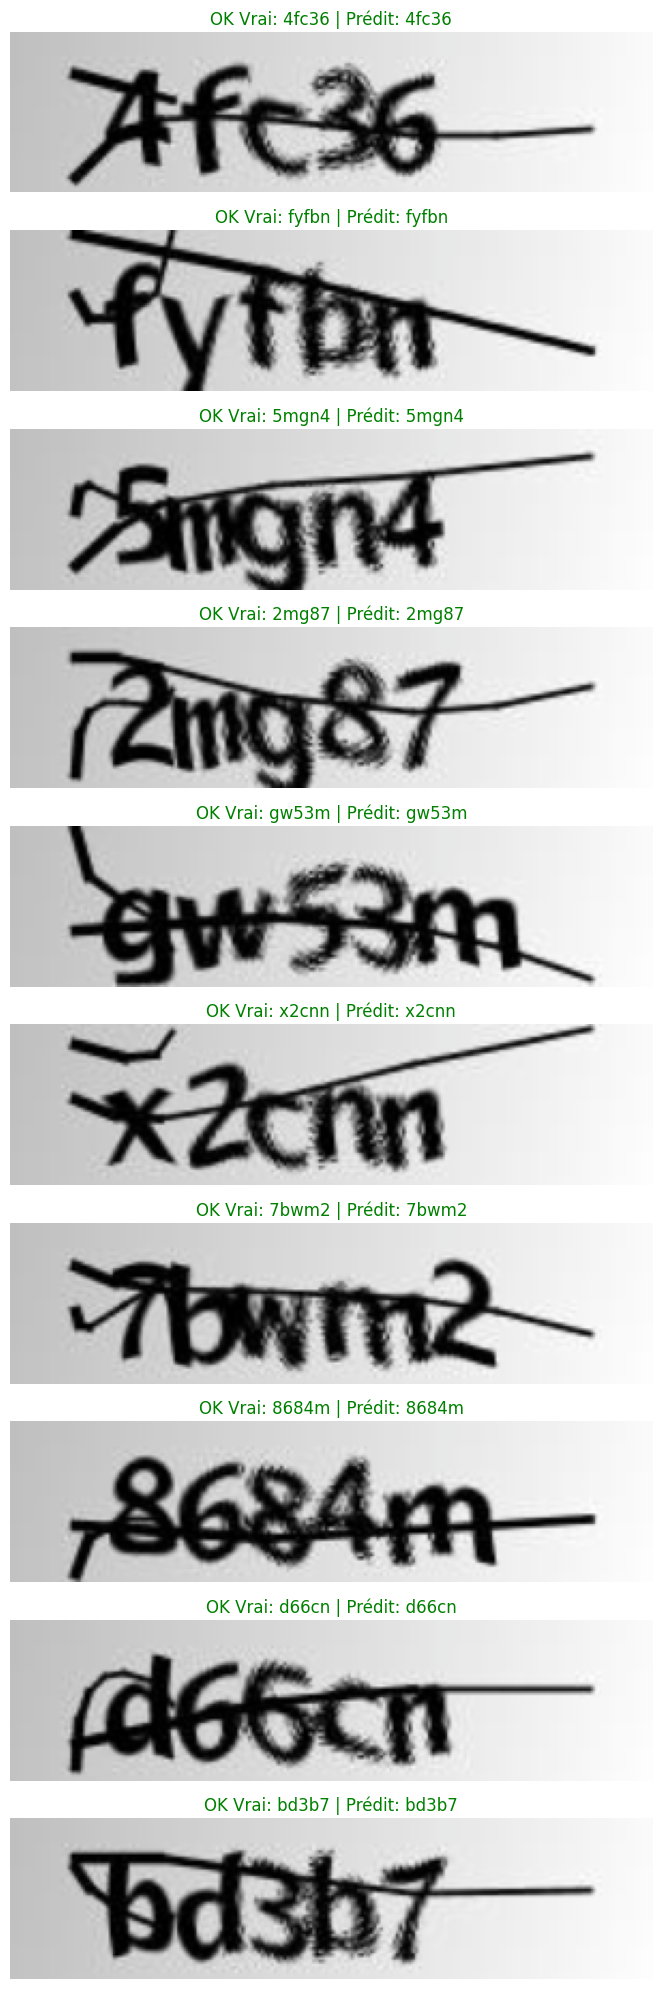

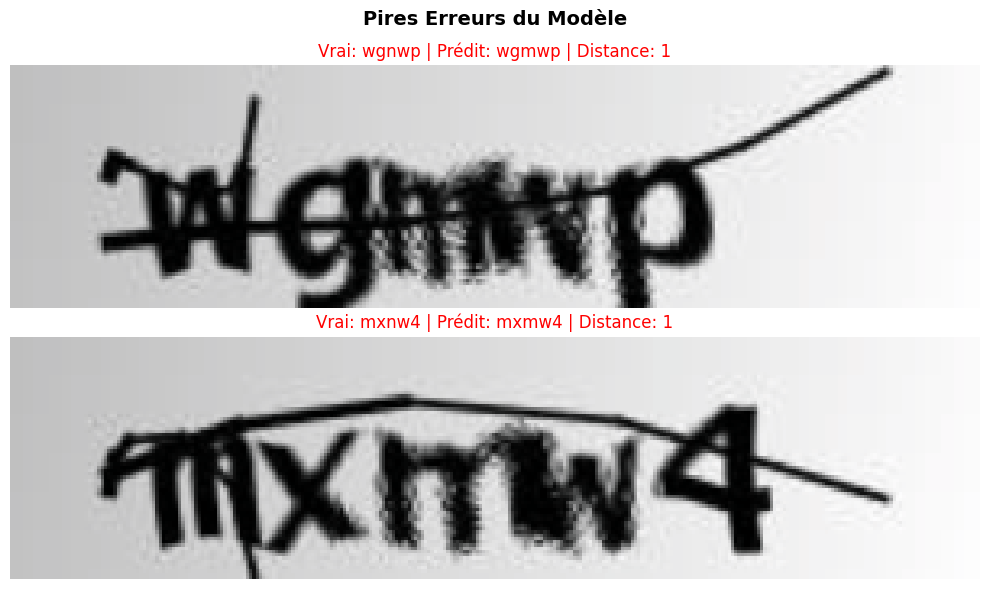

In [22]:
def visualize_predictions(
    model: nn.Module,
    loader: DataLoader,
    mapping: Dict[int, str],
    n_samples: int = 10
) -> None:
    """
    Affiche des exemples de prédictions (correctes et incorrectes).

    Args:
        model: Le modèle entraîné.
        loader: DataLoader à visualiser.
        mapping: Dictionnaire {index: caractère}.
        n_samples: Nombre d'exemples à afficher.
    """
    model.eval()

    samples = []

    with torch.no_grad():
        for batch in loader:
            images = batch["images"].to(DEVICE)
            targets = batch["targets"]

            preds, _ = model(images)
            decoded_preds = decode_predictions(preds, mapping)

            for i in range(images.size(0)):
                target_text = "".join([mapping[idx.item()] for idx in targets[i] if idx.item() != 0])
                pred_text = decoded_preds[i]
                is_correct = pred_text == target_text

                samples.append({
                    "image": images[i].cpu(),
                    "target": target_text,
                    "pred": pred_text,
                    "correct": is_correct
                })

            if len(samples) >= n_samples:
                break

    # Affichage
    fig, axes = plt.subplots(n_samples, 1, figsize=(10, 2 * n_samples))

    for i, sample in enumerate(samples[:n_samples]):
        img = sample["image"].permute(1, 2, 0).numpy()

        # Dé-normalisation pour affichage
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)

        status = "OK" if sample["correct"] else "KO"
        color = "green" if sample["correct"] else "red"
        axes[i].set_title(
            f"{status} Vrai: {sample['target']} | Prédit: {sample['pred']}",
            fontsize=12,
            color=color
        )
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


def visualize_worst_errors(
    model: nn.Module,
    loader: DataLoader,
    mapping: Dict[int, str],
    n_errors: int = 5
) -> None:
    """
    Affiche les erreurs les plus graves (plus grande distance d'édition).

    Args:
        model: Le modèle entraîné.
        loader: DataLoader à analyser.
        mapping: Dictionnaire {index: caractère}.
        n_errors: Nombre d'erreurs à afficher.
    """
    model.eval()

    errors = []

    with torch.no_grad():
        for batch in loader:
            images = batch["images"].to(DEVICE)
            targets = batch["targets"]

            preds, _ = model(images)
            decoded_preds = decode_predictions(preds, mapping)

            for i in range(images.size(0)):
                target_text = "".join([mapping[idx.item()] for idx in targets[i] if idx.item() != 0])
                pred_text = decoded_preds[i]
                distance = edit_distance(target_text, pred_text)

                if distance > 0:
                    errors.append({
                        "image": images[i].cpu(),
                        "target": target_text,
                        "pred": pred_text,
                        "distance": distance
                    })

    # Trier par distance décroissante
    errors.sort(key=lambda x: x["distance"], reverse=True)

    if len(errors) == 0:
        print("Aucune erreur trouvée !")
        return

    # Affichage
    n_display = min(n_errors, len(errors))
    fig, axes = plt.subplots(n_display, 1, figsize=(10, 3 * n_display))

    if n_display == 1:
        axes = [axes]

    for i, error in enumerate(errors[:n_display]):
        img = error["image"].permute(1, 2, 0).numpy()

        # Dé-normalisation
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].set_title(
            f"Vrai: {error['target']} | Prédit: {error['pred']} | Distance: {error['distance']}",
            fontsize=12,
            color="red"
        )
        axes[i].axis("off")

    plt.suptitle("Pires Erreurs du Modèle", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


visualize_predictions(model, test_loader, num_to_char, n_samples=10)
visualize_worst_errors(model, test_loader, num_to_char, n_errors=5)

# 15. Matrice de Confusion des Caractères

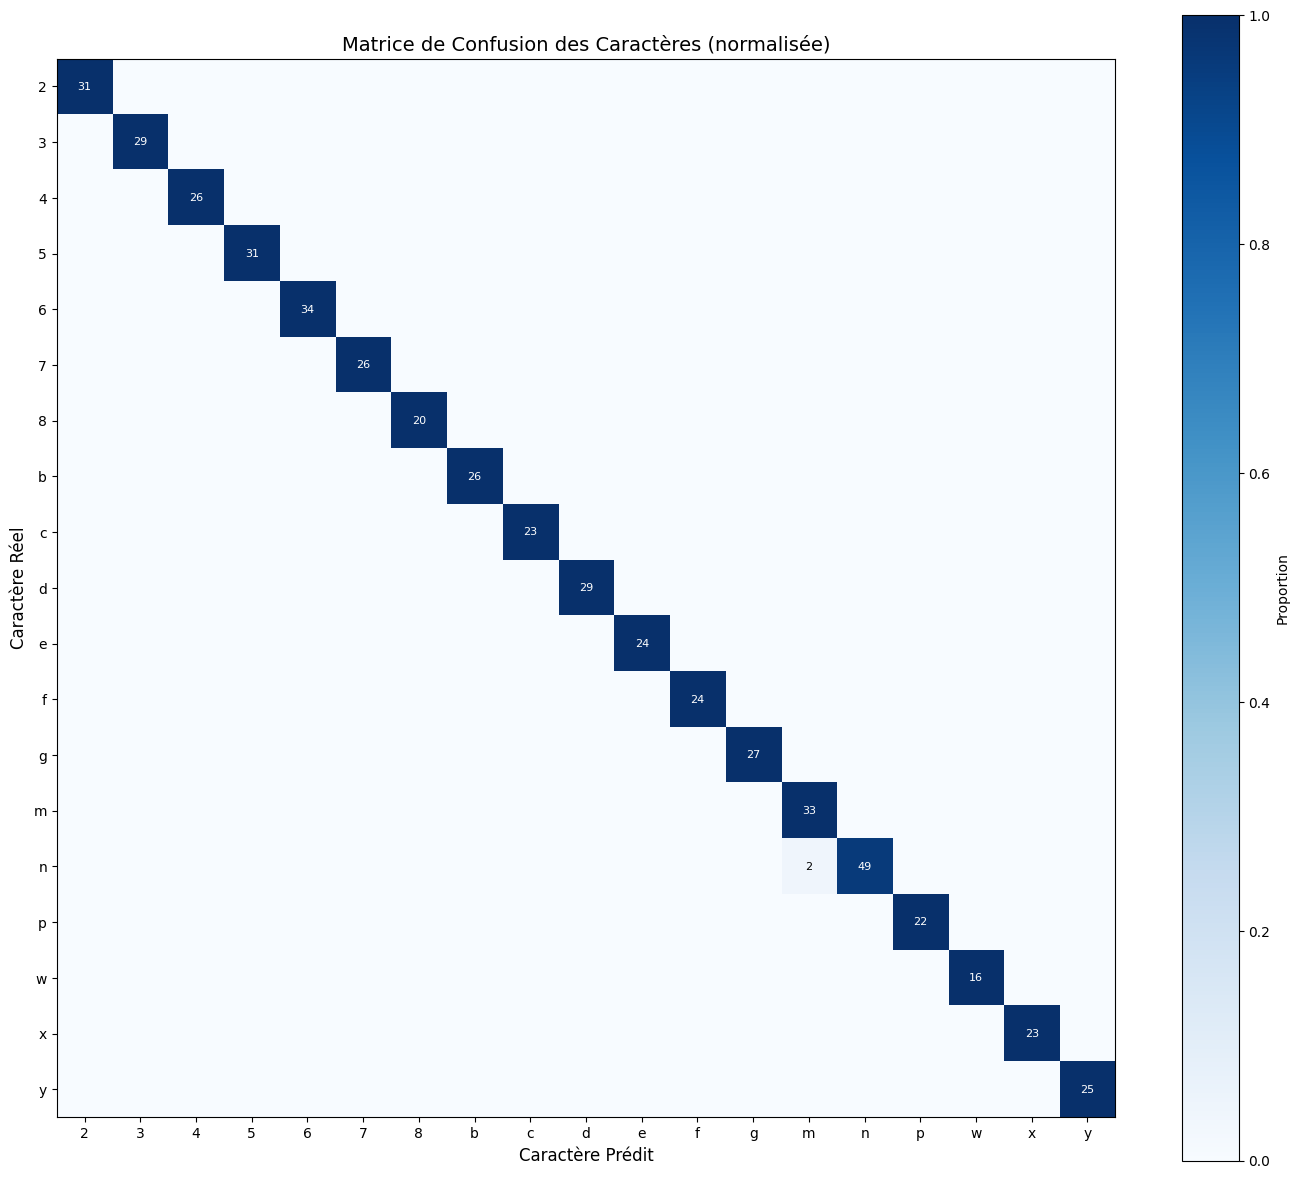


Confusions les plus fréquentes :
----------------------------------------
  'n' → 'm' : 2 fois


In [23]:
def plot_confusion_matrix(
    model: nn.Module,
    loader: DataLoader,
    mapping: Dict[int, str]
) -> None:
    """
    Affiche la matrice de confusion des caractères.

    Args:
        model: Le modèle entraîné.
        loader: DataLoader à analyser.
        mapping: Dictionnaire {index: caractère}.
    """
    model.eval()

    all_target_chars: List[str] = []
    all_pred_chars: List[str] = []

    with torch.no_grad():
        for batch in loader:
            images = batch["images"].to(DEVICE)
            targets = batch["targets"]

            preds, _ = model(images)
            decoded_preds = decode_predictions(preds, mapping)

            for pred, target in zip(decoded_preds, targets):
                target_text = "".join([mapping[idx.item()] for idx in target if idx.item() != 0])

                # Comparer caractère par caractère (si même longueur)
                if len(pred) == len(target_text):
                    all_target_chars.extend(list(target_text))
                    all_pred_chars.extend(list(pred))

    if len(all_target_chars) == 0:
        print("Pas assez de données pour la matrice de confusion")
        return

    # Créer la matrice
    labels = sorted(set(all_target_chars + all_pred_chars))
    cm = metrics.confusion_matrix(all_target_chars, all_pred_chars, labels=labels)

    # Affichage
    plt.figure(figsize=(14, 12))

    # Normaliser pour voir les pourcentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)  # Remplacer NaN par 0

    plt.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    plt.title("Matrice de Confusion des Caractères (normalisée)", fontsize=14)
    plt.colorbar(label="Proportion")

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, fontsize=10)
    plt.yticks(tick_marks, labels, fontsize=10)

    plt.xlabel("Caractère Prédit", fontsize=12)
    plt.ylabel("Caractère Réel", fontsize=12)

    # Ajouter les valeurs dans les cellules
    thresh = cm_normalized.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                plt.text(j, i, f"{cm[i, j]}",
                        ha="center", va="center",
                        color="white" if cm_normalized[i, j] > thresh else "black",
                        fontsize=8)

    plt.tight_layout()
    plt.show()

    # Afficher les confusions les plus fréquentes
    print("\nConfusions les plus fréquentes :")
    print("-" * 40)

    confusions = []
    for i, true_char in enumerate(labels):
        for j, pred_char in enumerate(labels):
            if i != j and cm[i, j] > 0:
                confusions.append((true_char, pred_char, cm[i, j]))

    confusions.sort(key=lambda x: x[2], reverse=True)

    for true_char, pred_char, count in confusions[:10]:
        print(f"  '{true_char}' → '{pred_char}' : {count} fois")


plot_confusion_matrix(model, test_loader, num_to_char)

# 16. Sauvegarde du Modèle et des Métadonnées

In [24]:
import joblib
from datetime import datetime

def save_model(
    model: nn.Module,
    mapping: Dict[str, Any],
    save_dir: str = ".",
    model_name: str = "captcha_model"
) -> None:
    """
    Sauvegarde le modèle et les métadonnées nécessaires pour l'inférence.

    Args:
        model: Le modèle entraîné.
        mapping: Dictionnaires char_to_num et num_to_char.
        save_dir: Dossier de sauvegarde.
        model_name: Nom de base des fichiers.
    """
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    # 1. Sauvegarde des poids du modèle
    model_path = save_path / f"{model_name}.pth"
    torch.save(model.state_dict(), model_path)

    # 2. Sauvegarde des métadonnées
    metadata = {
        "char_to_num": char_to_num,
        "num_to_char": num_to_char,
        "vocab": vocab,
        "image_width": IMAGE_WIDTH,
        "image_height": IMAGE_HEIGHT,
        "num_chars": len(vocab),
        "date_trained": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

    mapping_path = save_path / f"{model_name}_mapping.joblib"
    joblib.dump(metadata, mapping_path)

    print("=" * 50)
    print("MODÈLE SAUVEGARDÉ")
    print("=" * 50)
    print(f"Poids du modèle : {model_path}")
    print(f"Métadonnées : {mapping_path}")
    print(f"Vocabulaire : {len(vocab)} caractères")
    print(f"Date : {metadata['date_trained']}")
    print("=" * 50)


save_model(model, {"char_to_num": char_to_num, "num_to_char": num_to_char}, save_dir=MODELS_DIR)


MODÈLE SAUVEGARDÉ
Poids du modèle : C:\Users\htalbi\workspace\projet_API\models\captcha_model.pth
Métadonnées : C:\Users\htalbi\workspace\projet_API\models\captcha_model_mapping.joblib
Vocabulaire : 19 caractères
Date : 2025-12-29 14:42:44
